## Validation with Visualisation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../Data/Cleaned/customer_churn_dataset.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1.0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.0,9.0,1.0
1,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
2,2.0,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.0,20.0,0.0
3,3.0,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.0,21.0,0.0
4,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0


## Churn Problem Accessment

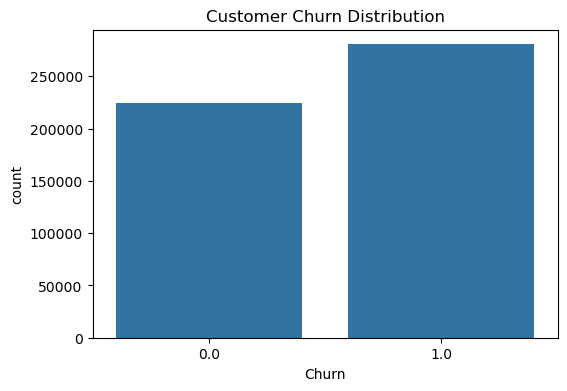

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")

plt.show()

In [5]:
df["Churn"].value_counts(normalize=True)*100

Churn
1.0    55.520322
0.0    44.479678
Name: proportion, dtype: float64

#### Observation

The dataset contains approximately 55.5% churned customers and 44.5% retained customers.

The target variable is reasonably balanced, making it suitable for further behavioral analysis.

## Univariate Analysis


### Support Calls

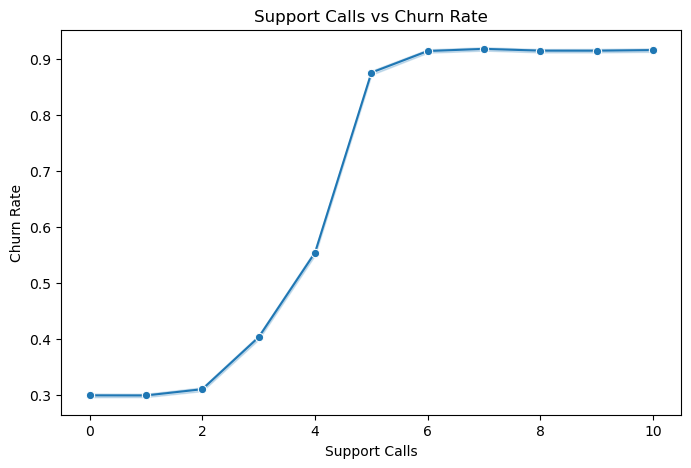

In [6]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df,
    x="Support Calls",
    y="Churn",
    marker="o"
)

plt.title("Support Calls vs Churn Rate")
plt.ylabel("Churn Rate")
plt.xlabel("Support Calls")

plt.show()

#### Observation

Customers with 0–2 support calls exhibit consistently low churn rates of approximately 30%, representing a stable low-risk segment.

Customers with 3–4 support calls show a noticeable increase in churn, with rates rising from approximately 40% to 55%, indicating a transition toward higher churn risk.

A sharp increase occurs beyond 4 support calls. Customers with 5 or more support calls consistently exhibit churn rates above 88%, forming a stable high-risk segment.

#### Conclusion

Support Calls demonstrate a strong nonlinear relationship with churn.

The relationship is characterized by three distinct behavioral regions:

- Low Risk: 0–2 support calls
- Transitional Risk: 3–4 support calls
- High Risk: 5+ support calls

The visual evidence strongly supports the issue-level segmentation identified during SQL analysis.

## Total Spend Analysis

In [7]:
spend_df = (
    df.groupby(pd.qcut(df["Total Spend"], q=20))
      .agg(
          churn_rate=("Churn","mean"),
          customer_count=("Churn","size")
      )
      .reset_index()
)

/tmp/ipykernel_6102/3173664209.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["Total Spend"], q=20))


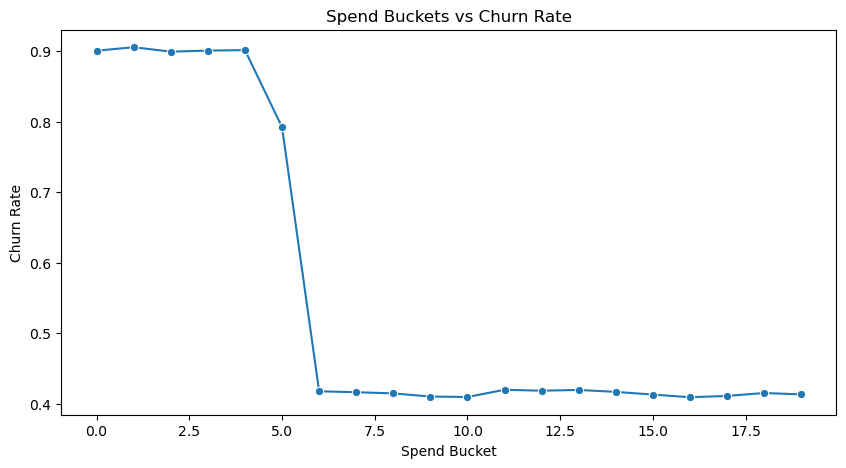

In [8]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=spend_df,
    x=spend_df.index,
    y="churn_rate",
    marker="o"
)

plt.title("Spend Buckets vs Churn Rate")
plt.xlabel("Spend Bucket")
plt.ylabel("Churn Rate")

plt.show()

In [9]:
spend_df

,Total Spend,churn_rate,customer_count
0,"(99.999, 169.0]",0.900542,25267
1,"(169.0, 239.0]",0.905478,25518
2,"(239.0, 308.0]",0.899187,25205
3,"(308.0, 378.0]",0.900716,25281
4,"(378.0, 446.0]",0.901377,25207
5,"(446.0, 508.0]",0.792131,25213
6,"(508.0, 543.0]",0.417439,25242
7,"(543.0, 578.0]",0.416137,25160
8,"(578.0, 613.32]",0.414462,25252
9,"(613.32, 648.9]",0.410007,25263


#### Observations and Conclusion

1. The churn rate drops sharply from 0.88 at the low spend level to 0.41 at the high spend level.
    - This indicates that the customers at low spend level are likely to churn.

2. The percentage difference between low and high spend levels is a high 72%.

3. The number of customers are comparable for low and high spend levels.

## Payment Delay Analysis

In [10]:
delay_df = (
    df.groupby(pd.qcut(df["Payment Delay"], q=20, duplicates="drop"))
      .agg(
          churn_rate=("Churn", "mean"),
          customer_count=("Churn", "size")
      )
      .reset_index()
)

delay_df

/tmp/ipykernel_6102/896682252.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["Payment Delay"], q=20, duplicates="drop"))


,Payment Delay,churn_rate,customer_count
0,"(-0.001, 1.0]",0.431270,37058
1,"(1.0, 2.0]",0.437585,18353
2,"(2.0, 4.0]",0.434140,37094
3,"(4.0, 5.0]",0.434688,18312
4,"(5.0, 6.0]",0.435307,18495
5,"(6.0, 8.0]",0.436745,37017
6,"(8.0, 9.0]",0.436396,18403
7,"(9.0, 10.0]",0.429427,18697
8,"(10.0, 12.0]",0.434676,37559
9,"(12.0, 13.0]",0.432497,18703


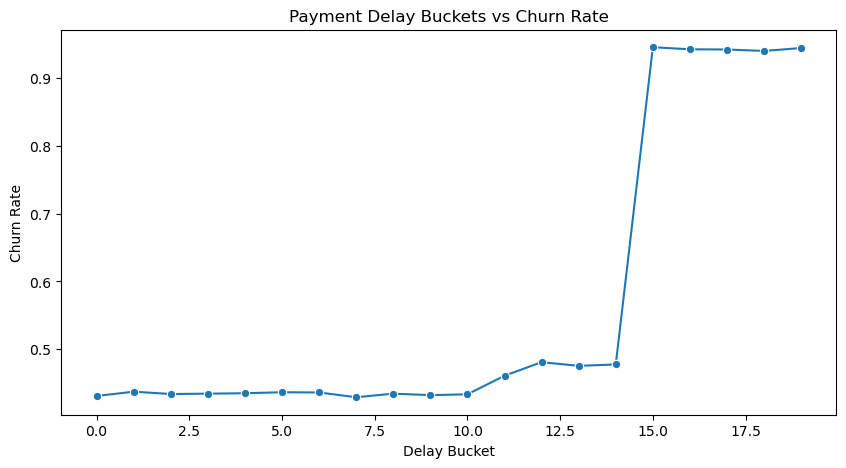

In [11]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=delay_df,
    x=delay_df.index,
    y="churn_rate",
    marker="o"
)

plt.title("Payment Delay Buckets vs Churn Rate")
plt.xlabel("Delay Bucket")
plt.ylabel("Churn Rate")

plt.show()

#### Observations and Conclusion

1. The churn rate increases sharply from 0.47 at the medium delay level to 0.94 at the high delay level.
    - This indicates that the customers at high delay level are likely to churn.

2. The percentage difference between low and medium delay levels is only 9.75% , but it jumps to 65.19% between medium and high delay levels.

3. The number of customers are comparable for for low and high delay levels , but slightly less for medium level.

## Contract length Analysis

In [12]:
contract_df = (
    df.groupby("Contract Length")
      .agg(
          churn_rate=("Churn", "mean"),
          customer_count=("Churn", "size")
      )
      .reset_index()
)

contract_df

,Contract Length,churn_rate,customer_count
0,Annual,0.460913,198608
1,Monthly,0.901963,109234
2,Quarterly,0.458169,197364


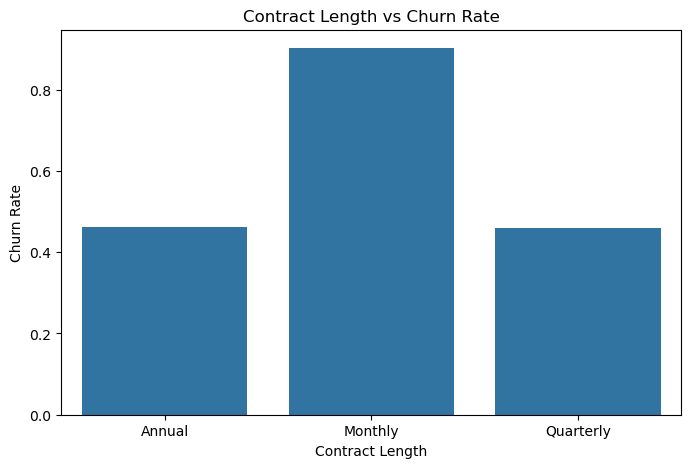

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=contract_df,
    x="Contract Length",
    y="churn_rate"
)

plt.title("Contract Length vs Churn Rate")
plt.xlabel("Contract Length")
plt.ylabel("Churn Rate")

plt.show()

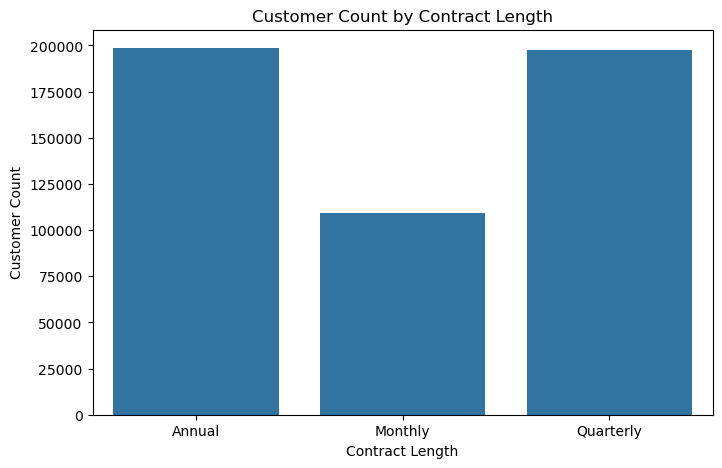

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=contract_df,
    x="Contract Length",
    y="customer_count"
)

plt.title("Customer Count by Contract Length")
plt.xlabel("Contract Length")
plt.ylabel("Customer Count")

plt.show()

#### Observations and Conclusion

1. The churn rate drops from 0.90 at the Monthly Contract_Length to 0.45 at the Quarterly Contract_Length	.

2. The percentage difference between Monthly and Quarterly Contract_Length is a High 64.7%.

3. The number of customers are comparable for each Contract_Length .

In [22]:
import numpy as np

df["Issue_Level"] = np.where(
    df["Support Calls"] <= 2,
    "Low Issues",
    np.where(df["Support Calls"] <= 4,
             "Medium Issues",
             "High Issues")
)

df["Delay_Level"] = np.where(
    df["Payment Delay"] <= 15,
    "Low Delay",
    np.where(df["Payment Delay"] <= 20,
             "Medium Delay",
             "High Delay")
)

df["Spend_Level"] = np.where(
    df["Total Spend"] <= 508,
    "Low Spend",
    "High Spend"
)

In [23]:
def plot_interaction(df, feature1, feature2):

    interaction_df = (
        df.groupby([feature1, feature2])
          .agg(
              churn_rate=("Churn", "mean"),
              customer_count=("Churn", "size")
          )
          .reset_index()
    )

    heatmap_df = interaction_df.pivot(
        index=feature1,
        columns=feature2,
        values="churn_rate"
    )

    plt.figure(figsize=(8,5))

    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".2f"
    )

    plt.title(f"{feature1} × {feature2}")
    plt.show()

    return interaction_df

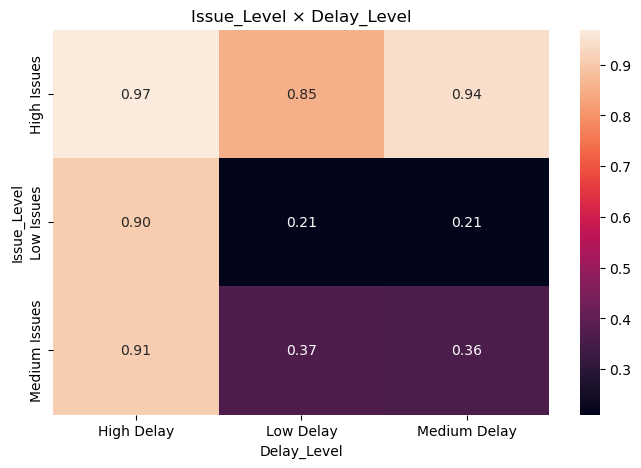

In [32]:
interaction_0 = plot_interaction(
    df,
    "Issue_Level",
    "Delay_Level"
)

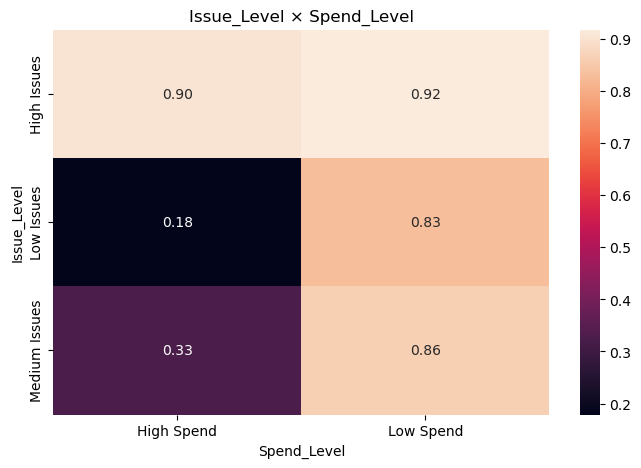

In [24]:
interaction_1 = plot_interaction(
    df,
    "Issue_Level",
    "Spend_Level"
)

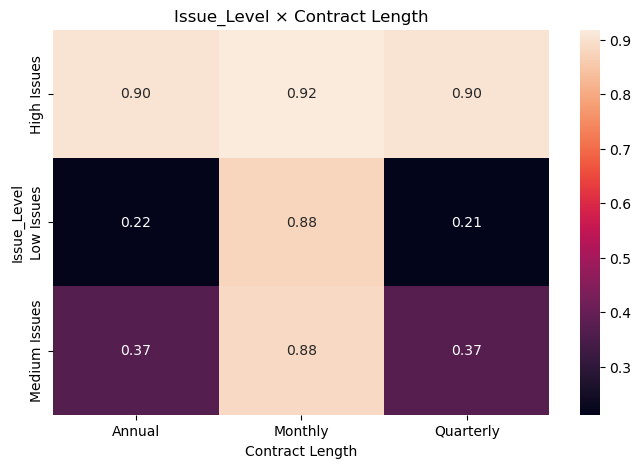

In [26]:
interaction_2 = plot_interaction(
    df,
    "Issue_Level",
    "Contract Length"
)

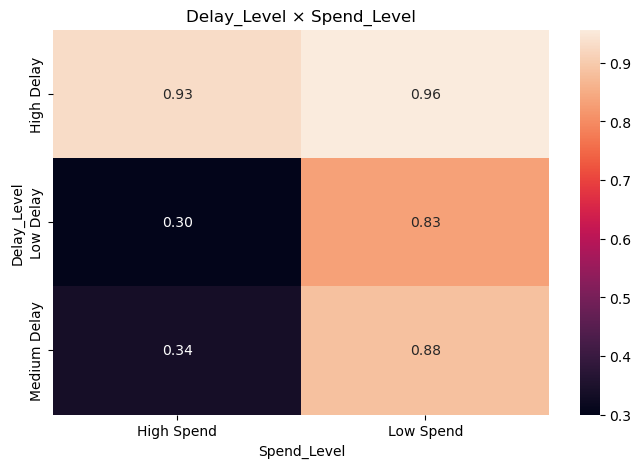

In [27]:
interaction_3 = plot_interaction(
    df,
    "Delay_Level",
    "Spend_Level"
)

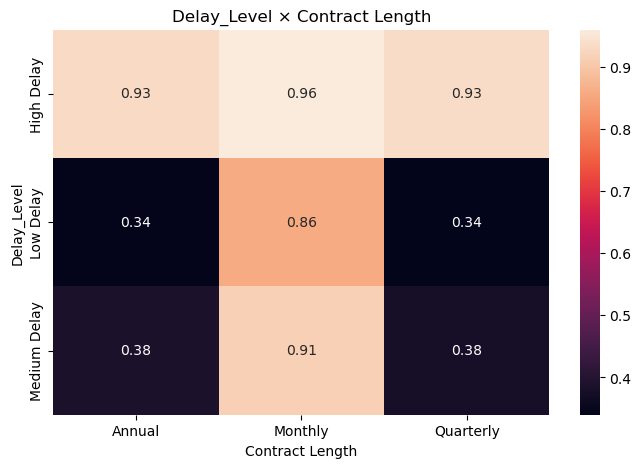

In [29]:
interaction_4 = plot_interaction(
    df,
    "Delay_Level",
    "Contract Length"
)

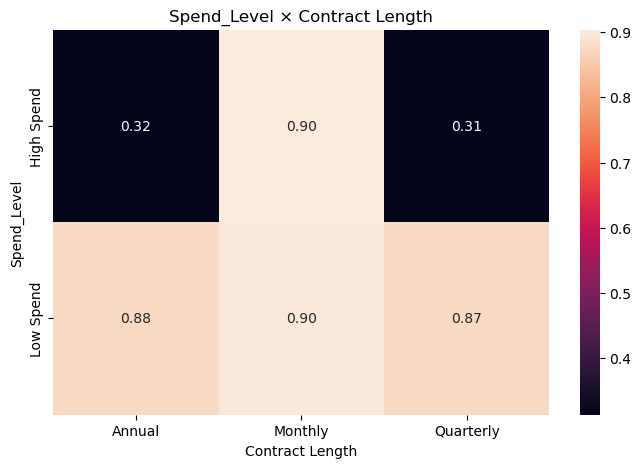

In [31]:
interaction_5 = plot_interaction(
    df,
    "Spend_Level",
    "Contract Length"
)

### Bivariate Analysis Summary

The bivariate analysis was performed to understand how combinations of important behavioral features influence customer churn.

#### Observations

1. Customers with both high issue levels and high payment delays show the highest churn rates, indicating that unresolved problems combined with delayed payments significantly increase churn risk.

2. High issue levels consistently result in elevated churn rates regardless of payment behavior, suggesting that customer dissatisfaction is a strong driver of churn.

3. Customers with low issue levels and low payment delays exhibit the lowest churn rates, representing the most stable customer segment.

4. Total spend modifies churn behavior. Customers with higher spending generally show lower churn rates, while low-spending customers are more likely to churn when combined with high issue levels or payment delays.

5. The interaction patterns observed in the bivariate analysis are consistent with the findings from the univariate analysis, indicating that Support Calls (Issue Level), Payment Delay, and Total Spend remain the most influential behavioral features.

#### Conclusion

The bivariate analysis confirms that churn is driven by the combined effect of customer issues, payment behavior, and spending patterns. Customers experiencing high issue levels and significant payment delays represent the highest-risk segment and should be prioritized for retention strategies.


multi_df = (
    df.groupby(
        [
            "Issue_Level",
            "Delay_Level",
            "Spend_Level",
            "Contract_Length"
        ]
    )
    .agg(
        churn_rate=("Churn", "mean"),
        customer_count=("Churn", "size")
    )
    .reset_index()
)

multi_df

## Multivariate Analysis

In [36]:
multi_df = (
    df.groupby(
        [
            "Issue_Level",
            "Delay_Level",
            "Spend_Level",
            "Contract Length"
        ]
    )
    .agg(
        churn_rate=("Churn", "mean"),
        customer_count=("Churn", "size")
    )
    .reset_index()
    .sort_values(
        by=["churn_rate", "customer_count"],
        ascending=[False, False]
    )
)

multi_df

,Issue_Level,Delay_Level,Spend_Level,Contract Length,churn_rate,customer_count
1,High Issues,High Delay,High Spend,Monthly,0.980108,11713
4,High Issues,High Delay,Low Spend,Monthly,0.977459,9627
5,High Issues,High Delay,Low Spend,Quarterly,0.976098,9790
3,High Issues,High Delay,Low Spend,Annual,0.973307,9778
2,High Issues,High Delay,High Spend,Quarterly,0.956104,11254
13,High Issues,Medium Delay,High Spend,Monthly,0.956094,5694
0,High Issues,High Delay,High Spend,Annual,0.952814,11338
16,High Issues,Medium Delay,Low Spend,Monthly,0.952806,4598
15,High Issues,Medium Delay,Low Spend,Annual,0.951018,4716
17,High Issues,Medium Delay,Low Spend,Quarterly,0.950280,4646


In [42]:
important_segments = multi_df[
    multi_df["customer_count"] >= 1000
].sort_values(
    "churn_rate",
    ascending=False
)

important_segments

,Issue_Level,Delay_Level,Spend_Level,Contract Length,churn_rate,customer_count
1,High Issues,High Delay,High Spend,Monthly,0.980108,11713
4,High Issues,High Delay,Low Spend,Monthly,0.977459,9627
5,High Issues,High Delay,Low Spend,Quarterly,0.976098,9790
3,High Issues,High Delay,Low Spend,Annual,0.973307,9778
2,High Issues,High Delay,High Spend,Quarterly,0.956104,11254
13,High Issues,Medium Delay,High Spend,Monthly,0.956094,5694
0,High Issues,High Delay,High Spend,Annual,0.952814,11338
16,High Issues,Medium Delay,Low Spend,Monthly,0.952806,4598
15,High Issues,Medium Delay,Low Spend,Annual,0.951018,4716
17,High Issues,Medium Delay,Low Spend,Quarterly,0.950280,4646


In [39]:
important_segments["segment"] = (
    important_segments["Issue_Level"] + " | " +
    important_segments["Delay_Level"] + " | " +
    important_segments["Spend_Level"] + " | " +
    important_segments["Contract Length"]
)

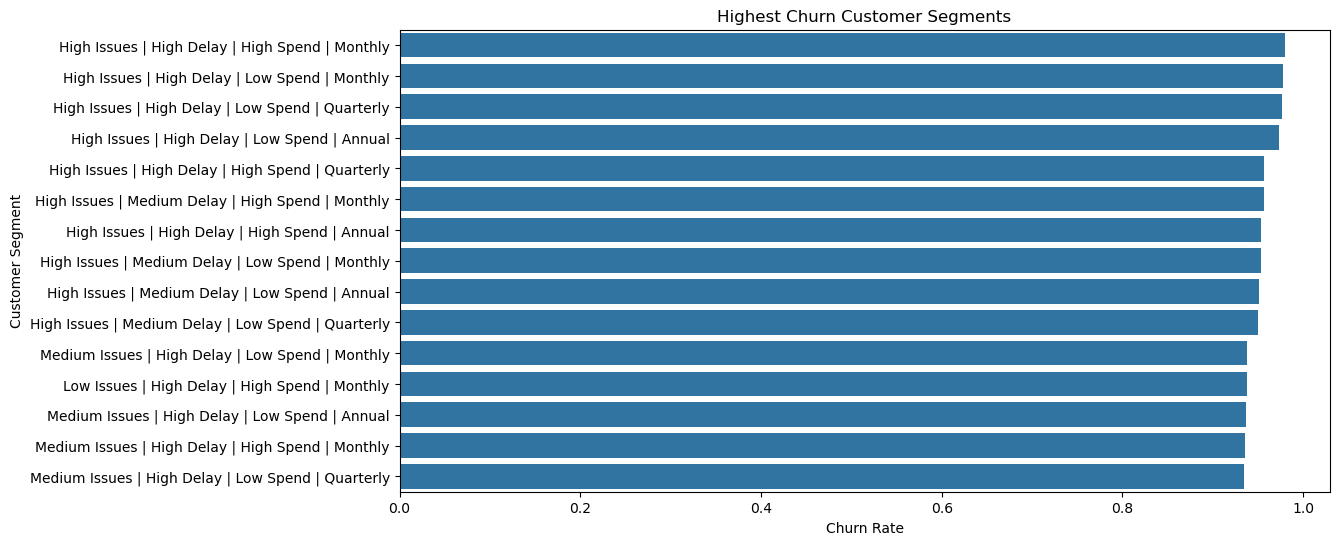

In [40]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=important_segments.head(15),
    x="churn_rate",
    y="segment"
)

plt.title("Highest Churn Customer Segments")
plt.xlabel("Churn Rate")
plt.ylabel("Customer Segment")

plt.show()

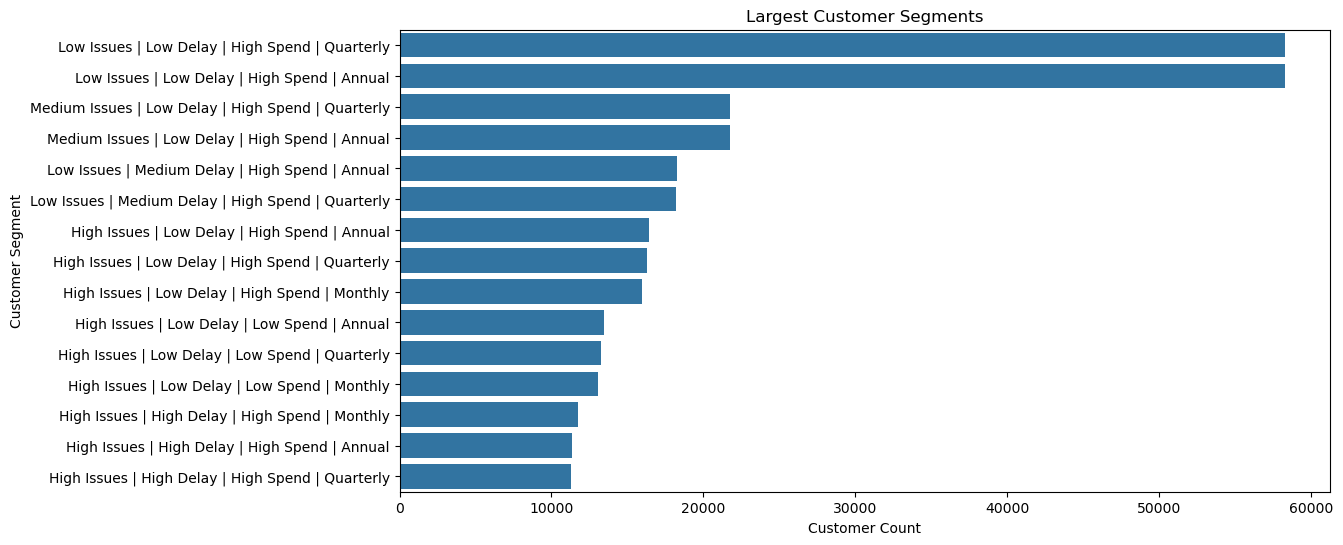

In [41]:
largest_segments = (
    important_segments
    .sort_values(
        "customer_count",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=largest_segments,
    x="customer_count",
    y="segment"
)

plt.title("Largest Customer Segments")
plt.xlabel("Customer Count")
plt.ylabel("Customer Segment")

plt.show()

### Cluster A: Committed Customers

#### Characteristics

* Customers belonging to this cluster are generally characterized by high spending behavior.
* They continue to invest a significant amount in the platform despite not always choosing the longest contract duration.
* Their spending behavior suggests a stronger relationship with the service compared to low-spending customers.

#### Observed Behavioral Pattern

* These customers are frequently observed across segments with high churn rates when service issues become severe.
* As issue levels increase, payment delays also tend to increase.
* Rather than immediately leaving the platform, these customers often continue using the service while delaying payments.
* Churn is most commonly observed when both issue levels and payment delays become high.

#### Possible Interpretation

One possible explanation is that these customers are highly engaged with the platform and derive value from the service. As a result, they may be more willing to tolerate temporary service issues than less committed customers.

Instead of immediately abandoning the platform, they appear to remain active while delaying payments, potentially indicating dissatisfaction combined with a willingness to give the platform additional opportunities to improve.

#### Hypothesis 1: Delayed Churn Due to High Tolerance

Customers in this segment may possess a higher tolerance for service-related issues. Rather than churning immediately, they remain with the platform despite growing dissatisfaction. Payment delays may therefore act as an early warning signal that customer patience is being exhausted.

Possible sequence:

High Spend Customer
→ Service Issues Increase
→ Support Calls Increase
→ Payment Delays Increase
→ Customer Continues Giving Chances
→ Eventually Churns

#### Hypothesis 2: Payment Delay as a Retention Warning Signal

For committed customers, payment delay may not immediately indicate an intention to leave. Instead, it may represent a transitional stage between satisfaction and churn.

Under this hypothesis, payment delay serves as a warning signal that the customer is dissatisfied but has not yet fully decided to leave the platform.

#### Business Implication

If this hypothesis is correct, high-spending customers with increasing support calls and payment delays should be prioritized for intervention. These customers may still be recoverable because they have already demonstrated a willingness to remain with the platform despite experiencing dissatisfaction.


### Cluster B: Low-Commitment Customers

#### Characteristics

* Customers belonging to this cluster are generally characterized by low spending behavior.
* They contribute relatively less revenue to the platform compared to high-spending customers.
* These customers may have a weaker relationship with the service and lower overall investment in the platform.

#### Observed Behavioral Pattern

* Customers in this segment frequently appear among high-churn groups when service issues begin to increase.
* Churn can occur even at moderate levels of issues and payment delays.
* Compared to committed customers, they appear less likely to remain with the platform once dissatisfaction develops.
* Payment delays are observed in some segments, but immediate churn is also common.

#### Possible Interpretation

One possible explanation is that these customers have a lower level of attachment to the platform. Since their spending and investment in the service are relatively low, the perceived cost of leaving may also be lower.

As a result, service issues may lead to churn more quickly than in highly committed customer segments.

#### Hypothesis 1: Lower Tolerance for Dissatisfaction

Customers in this segment may have a lower tolerance for service-related problems. Because they are less invested in the platform, they may be more willing to switch to alternatives when issues arise.

Possible sequence:

Low Spend Customer
→ Service Issues Increase
→ Dissatisfaction Develops
→ Immediate Churn

#### Hypothesis 2: Weak Customer Attachment

Low spending behavior may indicate a weaker customer relationship with the platform. Under this hypothesis, customers are not necessarily leaving because problems are more severe, but because they have fewer reasons to remain when problems occur.

Possible sequence:

Low Spend Customer
→ Moderate Service Issues
→ Limited Attachment to Platform
→ Customer Leaves

#### Hypothesis 3: Payment Delay as a Measure of Tolerance

Within this segment, payment delay may represent the customer's willingness to continue despite dissatisfaction.

Possible sequence:

Low Spend Customer
→ Service Issues Increase
→ Payment Delay Appears
→ Customer Gives Limited Additional Time
→ Churn

Customers who churn with little or no payment delay may represent the least committed group, while customers who continue delaying payments may still be attempting to remain with the platform.

#### Business Implication

If this hypothesis is correct, retaining these customers may require early intervention before dissatisfaction escalates. Since attachment to the platform appears weaker, even moderate service issues may trigger churn. Improving onboarding experience, customer engagement, and perceived value may reduce churn within this segment.
